# Amélioration de l’approche de classification

## Prérequis

Cette
étape
repose
sur
la
finalisation
de
l’étape
3.

Les
données
préparées
pour
la
modélisation
sont
disponibles, ainsi
qu’un
premier
benchmark
de
classification
comprenant
un
modèle
Dummy, un
modèle
linéaire
et
un
modèle
non - linéaire.

## Objectif

L’objectif
de
cette
étape
est
d’améliorer
la
modélisation
en
tenant
compte:

- du
déséquilibre
de
la
variable
cible;
- du
contexte
métier;
- de
la
nécessité
d’évaluer
le
modèle
de
manière
plus
robuste.

## Approche retenue

La
démarche
adoptée
dans
ce
notebook
est
la
suivante:

1.
reconstruire
les
données
de
modélisation;
2.
enrichir
les
features
par
un
peu
de
feature
engineering;
3.
réaliser
une
séparation
stratifiée
en
train
et
test;
4.
entraîner
un
modèle
non - linéaire
pondéré;
5.
évaluer
le
modèle
en
validation
croisée
stratifiée;
6.
utiliser
la
courbe
précision - rappel
pour
choisir
un
seuil
de
décision
plus
adapté
au
besoin
métier.

In [61]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder

pd.set_option ("display.max_columns", 200)
sns.set_theme (style="whitegrid")

## 1. Import des bibliothèques

Cette étape charge les outils nécessaires au feature engineering, à la stratification, à l’entraînement du modèle non-linéaire et à l’évaluation avancée.

In [62]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

df_central = pd.read_csv (DATA_PROCESSED / "df_central.csv")

df_central["a_quitte_l_entreprise"] = (
    df_central["a_quitte_l_entreprise"]
    .astype (str)
    .str.strip ( )
    .str.capitalize ( )
)

df_central["attrition_bin"] = df_central["a_quitte_l_entreprise"].apply (
    lambda x: 1 if x == "Oui" else 0
)

print (df_central.shape)
display (df_central.head ( ))

(1470, 35)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0


In [63]:
def split_features_by_type(df: pd.DataFrame):
    num_cols = df.select_dtypes (include=["number"]).columns.tolist ( )
    cat_cols = df.select_dtypes (include=["object", "string", "category"]).columns.tolist ( )
    return num_cols, cat_cols


def build_target(df: pd.DataFrame, target_col: str = "attrition_bin") -> pd.Series:
    return df[target_col].copy ( )


def build_feature_matrix(
        df: pd.DataFrame,
        cols_to_drop: list[str] | None = None
) -> pd.DataFrame:
    if cols_to_drop is None:
        cols_to_drop = [
            "a_quitte_l_entreprise",
            "attrition_bin",
            "id_employee",
            "code_sondage",
            "eval_number",
        ]
    return df.drop (columns=[col for col in cols_to_drop if col in df.columns]).copy ( )


def fit_encoder_on_train(df: pd.DataFrame):
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if not cat_cols:
        return None, df

    encoder = OneHotEncoder (
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    encoded_array = encoder.fit_transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    df_encoded = pd.concat ([df[num_cols], encoded_df], axis=1)
    return encoder, df_encoded


def transform_with_encoder(df: pd.DataFrame, encoder) -> pd.DataFrame:
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if encoder is None or not cat_cols:
        return df

    encoded_array = encoder.transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    return pd.concat ([df[num_cols], encoded_df], axis=1)


def drop_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.8):
    corr_matrix = df.corr (numeric_only=True).abs ( )
    upper = corr_matrix.where (np.triu (np.ones (corr_matrix.shape), k=1).astype (bool))
    to_drop = [column for column in upper.columns if any (upper[column] > threshold)]
    return df.drop (columns=to_drop), to_drop

In [64]:
df_fe = df_central.copy ( )

df_fe["revenu_par_annee_experience"] = (
        df_fe["revenu_mensuel"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_entreprise"] = (
        df_fe["annees_dans_l_entreprise"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_poste"] = (
        df_fe["annees_dans_le_poste_actuel"] / (df_fe["annees_dans_l_entreprise"] + 1)
)

df_fe["charge_distance"] = (
        df_fe["distance_domicile_travail"] * df_fe["nombre_heures_travailless"]
)

satisfaction_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

df_fe["score_satisfaction_moyen"] = df_fe[satisfaction_cols].mean (axis=1)

print (df_fe.shape)
display (df_fe.head ( ))

(1470, 40)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin,revenu_par_annee_experience,part_anciennete_entreprise,part_anciennete_poste,charge_distance,score_satisfaction_moyen
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1,665.888889,0.666667,0.571429,80,2.00
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0,466.363636,0.909091,0.636364,640,3.00
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1,261.250000,0.000000,0.000000,160,3.00
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0,323.222222,0.888889,0.777778,240,3.25
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0,495.428571,0.285714,0.666667,160,2.50


## 2. Feature engineering

Quelques variables dérivées sont ajoutées afin d’enrichir la représentation initiale des employés.

L’objectif n’est pas de multiplier artificiellement les features, mais de créer des variables synthétiques plausibles au regard du contexte métier, par exemple en combinant revenu, expérience, ancienneté, charge de travail ou satisfaction.

In [65]:
y = build_target (df_fe)
X_raw = build_feature_matrix (df_fe)

X_train_raw, X_test_raw, y_train, y_test = train_test_split (
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print ("X_train_raw :", X_train_raw.shape)
print ("X_test_raw  :", X_test_raw.shape)
print ("y_train     :", y_train.shape)
print ("y_test      :", y_test.shape)

print ("\nRépartition y_train :")
print (y_train.value_counts (normalize=True))

print ("\nRépartition y_test :")
print (y_test.value_counts (normalize=True))

X_train_raw : (1176, 35)
X_test_raw  : (294, 35)
y_train     : (1176,)
y_test      : (294,)

Répartition y_train :
attrition_bin
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Répartition y_test :
attrition_bin
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [66]:
encoder, X_train_prepared = fit_encoder_on_train (X_train_raw)
X_test_prepared = transform_with_encoder (X_test_raw, encoder)

X_train, dropped_corr_features = drop_highly_correlated_features (
    X_train_prepared,
    threshold=0.8
)

X_test = X_test_prepared.drop (columns=dropped_corr_features, errors="ignore")

X_train, X_test = X_train.align (
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print ("Shape final de X_train :", X_train.shape)
print ("Shape final de X_test  :", X_test.shape)
print ("NaN dans X_train :", X_train.isna ( ).sum ( ).sum ( ))
print ("NaN dans X_test  :", X_test.isna ( ).sum ( ).sum ( ))
print ("Variables supprimées :", dropped_corr_features)

Shape final de X_train : (1176, 58)
Shape final de X_test  : (294, 58)
NaN dans X_train : 0
NaN dans X_test  : 0
Variables supprimées : ['niveau_hierarchique_poste', 'charge_distance', 'poste_Ressources Humaines']


## 3. Séparation stratifiée des données

Les jeux d’apprentissage et de test sont construits à l’aide d’une stratification sur la cible afin de conserver une répartition comparable des classes dans les deux sous-ensembles.

In [67]:
rf_model = RandomForestClassifier (
    n_estimators=400,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [68]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split (
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

rf_model.fit (X_subtrain, y_subtrain)

y_scores_valid = rf_model.predict_proba (X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve (y_valid, y_scores_valid)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

threshold_df = pd.DataFrame ({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_scores,
})

best_threshold_row = threshold_df.sort_values ("f1", ascending=False).iloc[0]
best_threshold = float (best_threshold_row["threshold"])
display (best_threshold_row)

threshold    0.459422
precision    0.513514
recall       0.500000
f1           0.506667
Name: 199, dtype: float64

## 4. Modèle non-linéaire retenu

Le modèle retenu est une Random Forest pondérée par `class_weight="balanced"` afin de mieux tenir compte du déséquilibre de la variable cible.

L’objectif est d’améliorer la détection des départs tout en limitant le surapprentissage observé à l’étape précédente.

In [69]:
def evaluate_cv_model(model, X, y, n_splits=5):
    skf = StratifiedKFold (n_splits=n_splits, shuffle=True, random_state=42)

    fold_metrics = []

    for fold_idx, (train_idx, valid_idx) in enumerate (skf.split (X, y), start=1):
        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        model.fit (X_fold_train, y_fold_train)

        y_pred_train = model.predict (X_fold_train)
        y_pred_valid = model.predict (X_fold_valid)

        fold_metrics.append ({
            "fold": fold_idx,
            "train_accuracy": accuracy_score (y_fold_train, y_pred_train),
            "train_precision": precision_score (y_fold_train, y_pred_train, zero_division=0),
            "train_recall": recall_score (y_fold_train, y_pred_train, zero_division=0),
            "train_f1": f1_score (y_fold_train, y_pred_train, zero_division=0),
            "valid_accuracy": accuracy_score (y_fold_valid, y_pred_valid),
            "valid_precision": precision_score (y_fold_valid, y_pred_valid, zero_division=0),
            "valid_recall": recall_score (y_fold_valid, y_pred_valid, zero_division=0),
            "valid_f1": f1_score (y_fold_valid, y_pred_valid, zero_division=0),
        })

    return pd.DataFrame (fold_metrics)

In [70]:
cv_results = evaluate_cv_model (rf_model, X_train, y_train, n_splits=5)
display (cv_results)

,fold,train_accuracy,train_precision,train_recall,train_f1,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,0.959574,0.860759,0.894737,0.877419,0.885593,0.720000,0.473684,0.571429
1,2,0.950053,0.834395,0.861842,0.847896,0.829787,0.437500,0.184211,0.259259
2,3,0.956429,0.858065,0.875000,0.866450,0.872340,0.653846,0.447368,0.531250
3,4,0.944740,0.833333,0.822368,0.827815,0.868085,0.684211,0.342105,0.456140
4,5,0.953241,0.837500,0.881579,0.858974,0.846809,0.533333,0.421053,0.470588


In [71]:
cv_summary = cv_results.drop (columns="fold").agg (["mean", "std"]).T
display (cv_summary)

,mean,std
train_accuracy,0.952808,0.005740
train_precision,0.844810,0.013451
train_recall,0.867105,0.027679
train_f1,0.855711,0.018951
valid_accuracy,0.860523,0.022125
valid_precision,0.605778,0.117340
valid_recall,0.373684,0.116802
valid_f1,0.457733,0.120303


## 5. Validation croisée stratifiée

Une validation croisée stratifiée est utilisée afin d’obtenir une estimation plus robuste de la performance du modèle.

Les métriques sont stockées pour chaque fold, puis synthétisées à l’aide de la moyenne et de l’écart-type. Cela permet d’évaluer :

- la stabilité du modèle ;
- sa capacité de généralisation ;
- l’existence éventuelle d’un surapprentissage.

In [72]:
rf_model.fit (X_train, y_train)

y_pred_train = rf_model.predict (X_train)
y_pred_test = rf_model.predict (X_test)

results_final = pd.DataFrame ([
    {
        "split": "train",
        "accuracy": accuracy_score (y_train, y_pred_train),
        "precision": precision_score (y_train, y_pred_train, zero_division=0),
        "recall": recall_score (y_train, y_pred_train, zero_division=0),
        "f1": f1_score (y_train, y_pred_train, zero_division=0),
    },
    {
        "split": "test",
        "accuracy": accuracy_score (y_test, y_pred_test),
        "precision": precision_score (y_test, y_pred_test, zero_division=0),
        "recall": recall_score (y_test, y_pred_test, zero_division=0),
        "f1": f1_score (y_test, y_pred_test, zero_division=0),
    },
]).round (3)

display (results_final)

,split,accuracy,precision,recall,f1
0,train,0.949,0.832,0.858,0.845
1,test,0.820,0.417,0.319,0.361


In [73]:
print ("TRAIN")
print (classification_report (y_train, y_pred_train, zero_division=0))

print ("TEST")
print (classification_report (y_test, y_pred_test, zero_division=0))

TRAIN
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       986
           1       0.83      0.86      0.84       190

    accuracy                           0.95      1176
   macro avg       0.90      0.91      0.91      1176
weighted avg       0.95      0.95      0.95      1176

TEST
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.42      0.32      0.36        47

    accuracy                           0.82       294
   macro avg       0.65      0.62      0.63       294
weighted avg       0.80      0.82      0.81       294



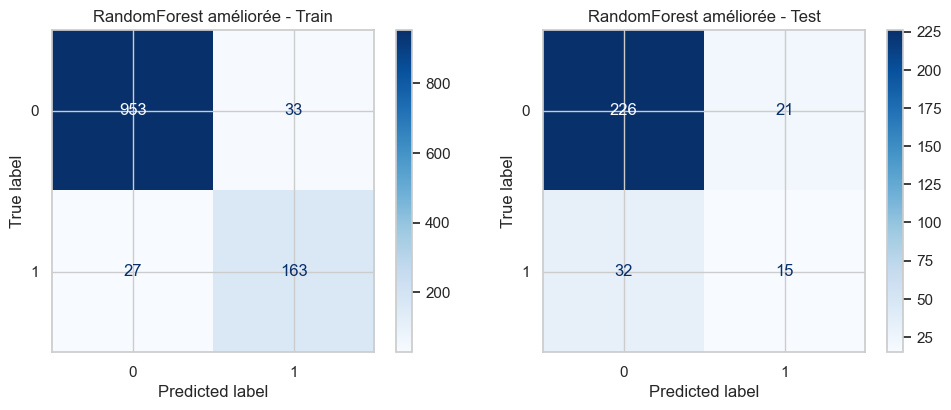

In [74]:
fig, axes = plt.subplots (1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions (y_train, y_pred_train, ax=axes[0], cmap="Blues")
axes[0].set_title ("RandomForest améliorée - Train")

ConfusionMatrixDisplay.from_predictions (y_test, y_pred_test, ax=axes[1], cmap="Blues")
axes[1].set_title ("RandomForest améliorée - Test")

plt.tight_layout ( )
plt.show ( )

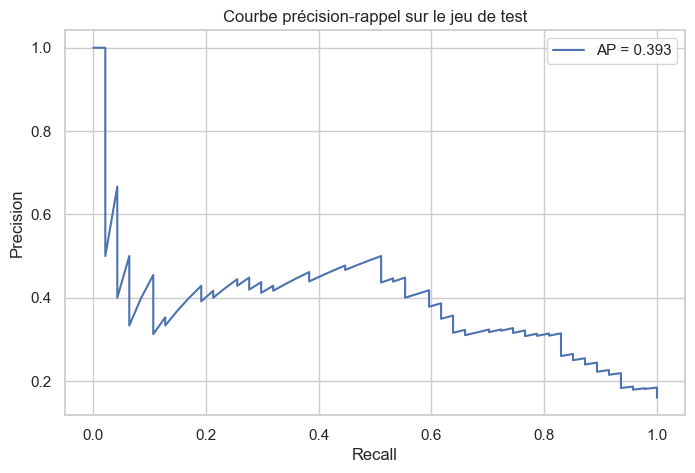

,threshold,accuracy,precision,recall,f1
0,0.459,0.837,0.489,0.489,0.489


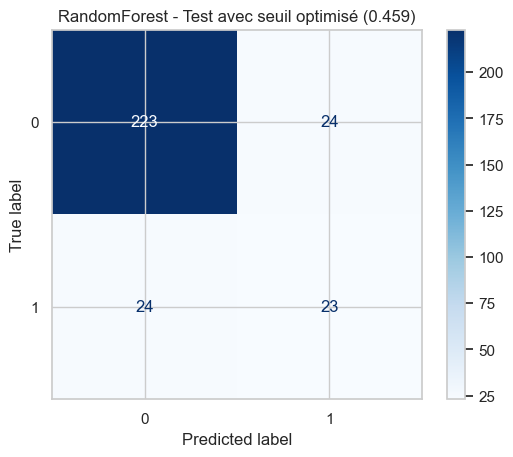

In [75]:
y_scores_test = rf_model.predict_proba (X_test)[:, 1]

precision_test, recall_test, _ = precision_recall_curve (y_test, y_scores_test)
ap_score = average_precision_score (y_test, y_scores_test)

plt.figure (figsize=(8, 5))
plt.plot (recall_test, precision_test, label=f"AP = {ap_score:.3f}")
plt.xlabel ("Recall")
plt.ylabel ("Precision")
plt.title ("Courbe précision-rappel sur le jeu de test")
plt.legend ( )
plt.show ( )

y_pred_test_threshold = (y_scores_test >= best_threshold).astype (int)

threshold_results = pd.DataFrame ([{
    "threshold": round (best_threshold, 3),
    "accuracy": accuracy_score (y_test, y_pred_test_threshold),
    "precision": precision_score (y_test, y_pred_test_threshold, zero_division=0),
    "recall": recall_score (y_test, y_pred_test_threshold, zero_division=0),
    "f1": f1_score (y_test, y_pred_test_threshold, zero_division=0),
}]).round (3)

display (threshold_results)

ConfusionMatrixDisplay.from_predictions (y_test, y_pred_test_threshold, cmap="Blues")
plt.title (f"RandomForest - Test avec seuil optimisé ({best_threshold:.3f})")
plt.show ( )

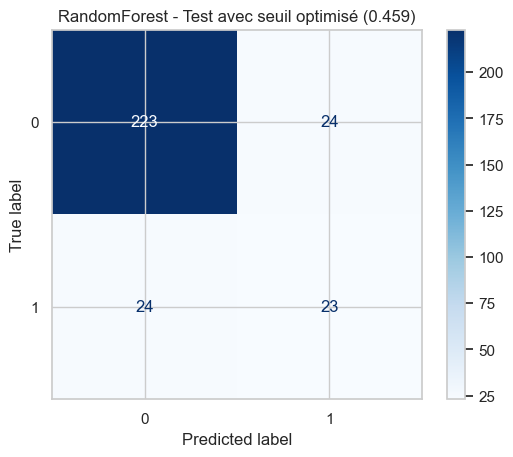

In [76]:
ConfusionMatrixDisplay.from_predictions (y_test, y_pred_test_threshold, cmap="Blues")
plt.title (f"RandomForest - Test avec seuil optimisé ({best_threshold:.3f})")
plt.show ( )

## 6. Ajustement du seuil de décision

La courbe précision-rappel permet d’ajuster le seuil de classification au lieu de conserver automatiquement le seuil par défaut de 0.5.

Cette étape est importante dans un contexte déséquilibré, car elle permet d’adapter le compromis entre precision et recall au besoin métier.

Si l’objectif prioritaire est d’identifier le plus grand nombre possible d’employés à risque de départ, un seuil favorisant le recall peut être pertinent, au prix d’une baisse de précision.

## 7. Interprétation des performances du modèle amélioré

La validation croisée montre que le modèle non-linéaire amélioré présente encore un écart entre les performances d’apprentissage et de validation, ce qui suggère un surapprentissage modéré. Néanmoins, cet écart reste nettement plus maîtrisé que lors de l’étape précédente.

Avec le seuil de décision standard, le modèle obtient une accuracy correcte sur le jeu de test, mais son recall sur la classe positive reste relativement faible. Cela signifie qu’une part importante des employés quittant réellement l’entreprise n’est pas détectée.

L’utilisation de la courbe précision-rappel pour ajuster le seuil de décision permet d’obtenir un compromis plus cohérent avec le contexte métier. Après optimisation du seuil, le modèle atteint un meilleur équilibre entre precision et recall, avec un score F1 sensiblement amélioré.

Ce résultat montre l’intérêt d’adapter le seuil de classification dans un contexte déséquilibré, plutôt que de conserver automatiquement le seuil par défaut de 0.5.

## Conclusion

Cette étape a permis d’améliorer l’approche de classification en tenant compte du déséquilibre des classes et du besoin métier.

Les principales améliorations apportées sont :

- une séparation stratifiée des données ;
- l’ajout de features dérivées ;
- l’utilisation d’un modèle non-linéaire pondéré ;
- une validation croisée stratifiée ;
- l’ajustement du seuil de décision à l’aide de la courbe précision-rappel.

Le modèle obtenu reste imparfait, mais il offre un compromis plus pertinent que les approches précédentes, en particulier après optimisation du seuil. Il constitue donc une base plus robuste pour la suite du projet et pour l’interprétation des facteurs de départ.